In [1]:
import MetaTrader5 as mt5
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import yfinance as yf
import ta
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import pickle
from sklearn.preprocessing import MinMaxScaler

In [4]:
tickers = 'EURUSD=X'
start = '2020-03-16'
end = '2025-03-16'
interval = mt5.TIMEFRAME_D1

bars = 1000

In [5]:
def hma(close, window):
    """Calculate Hull Moving Average (HMA)."""
    wma_half = ta.trend.WMAIndicator(close, window=int(window/2)).wma()
    wma_full = ta.trend.WMAIndicator(close, window=window).wma()
    hma_sqrt = int(np.sqrt(window))
    return ta.trend.WMAIndicator(2 * wma_half - wma_full, window=hma_sqrt).wma()

def tema(close, window):
    """Calculate Triple Exponential Moving Average (TEMA)."""
    ema1 = ta.trend.ema_indicator(close, window=window)
    ema2 = ta.trend.ema_indicator(ema1, window=window)
    ema3 = ta.trend.ema_indicator(ema2, window=window)
    return 3 * ema1 - 3 * ema2 + ema3

def calculate_cmo(close, window=14):

    # Calculate daily price changes
    price_change = close.diff()

    # Separate gains and losses
    gain = price_change.apply(lambda x: x if x > 0 else 0)
    loss = price_change.apply(lambda x: -x if x < 0 else 0)

    # Calculate the sum of gains and losses over the window
    sum_gain = gain.rolling(window=window).sum()
    sum_loss = loss.rolling(window=window).sum()

    # Calculate CMO
    cmo = ((sum_gain - sum_loss) / (sum_gain + sum_loss)) * 100
    return cmo


def get_data(tickers, start, end, interval, bars):
    # data=yf.download(tickers, start=start, end=end, interval =interval)

    # if isinstance(data.columns, pd.MultiIndex):
    #     data.columns = data.columns.get_level_values(0)

    mt5.initialize()

    rates = mt5.copy_rates_from_pos("EURUSD", interval ,0,bars)

    data = pd.DataFrame(rates)
    data['time'] = pd.to_datetime(data['time'], unit='s')

    data.rename(columns={'close': 'Close', 'high': 'High', 'time':'Date', 'low': 'Low', 'open':'Open'}, inplace=True)

    data.drop(columns= ['spread', 'real_volume'], inplace = True)

    data.set_index('Date', inplace=True)

    data.index = pd.to_datetime(data.index)


    data['RSI'] = ta.momentum.rsi(data['Close'], window=14)

    data['Williams_%R'] = ta.momentum.WilliamsRIndicator(
        high=data['High'], 
        low=data['Low'], 
        close=data['Close'], 
        lbp=14  # Lookback period (default is 14)
    ).williams_r()

    data['WMA'] = ta.trend.WMAIndicator(close=data['Close'], window=50).wma()

    data['HMA'] = hma(data['Close'], 50)  # 50-period HMA

    data['EMA'] = ta.trend.ema_indicator(close=data['Close'], window=50)

    data['SMA'] = ta.trend.sma_indicator(close=data['Close'], window=50)

    data['TEMA'] = tema(data['Close'], 50)

    data['CCI'] = ta.trend.CCIIndicator(
        high=data['High'], 
        low=data['Low'], 
        close=data['Close'], 
        window=14
    ).cci()

    data['CMO'] = calculate_cmo(data['Close'], window=14)

    data['MACD'] = ta.trend.MACD(close=data['Close'], window_fast=12, window_slow= 26).macd()

    data['PPO'] = ta.momentum.PercentagePriceOscillator(close=data['Close'], window_fast=12, window_slow= 26).ppo()

    data['ROC'] = ta.momentum.ROCIndicator(close=data['Close']).roc()

    data['DMI'] = ta.trend.ADXIndicator(
        high=data['High'], 
        low=data['Low'], 
        close=data['Close'], 
        window=14
    ).adx()

    data['MFI'] = ta.volume.MFIIndicator(
        high=data['High'], 
        low=data['Low'], 
        close=data['Close'],
        volume  = data['tick_volume'],
        window=14
    ).money_flow_index()

    data = data.dropna()


    return data


data = get_data(tickers, start, end, interval, bars)
data

KeyError: 'time'

In [4]:
features = []
for i in data.columns:
    features.append(i)

target = 'Close'

In [5]:
# Feature scaler (for technical indicators)
scaler_features = MinMaxScaler()
scaled_features = scaler_features.fit_transform(data[features])

# Target scaler (for Close price only)
scaler_target = MinMaxScaler()
scaled_target = scaler_target.fit_transform(data[[target]])

# Convert back to DataFrame for easy manipulation
df_scaled = pd.DataFrame(scaled_features, columns=features)
df_scaled['Close'] = scaled_target  # Add scaled Close price

In [6]:
train_size = int(len(data) * 0.9) # 80% for training

# Split into training and test sets
df_train = df_scaled.iloc[:train_size]
df_test = df_scaled.iloc[train_size:]

# Fit the scalers to the training data
scaler_features.fit(df_train[features])  # Fit scaler to features
scaler_target.fit(df_train[[target]])  # Fit scaler to target column

# Save the scalers to .pkl files
with open('scaler_features.pkl', 'wb') as f:
    pickle.dump(scaler_features, f)

with open('scaler_target.pkl', 'wb') as f:
    pickle.dump(scaler_target, f)


In [7]:
# from sklearn.model_selection import train_test_split

# # Define the train-test split ratio
# train_size = 0.8  # 80% for training

# # Randomly split the dataset
# df_train, df_test = train_test_split(df_scaled, train_size=train_size, random_state=42, shuffle=True)


# # Fit the scalers to the training data
# scaler_features.fit(df_train[features])  # Fit scaler to features
# scaler_target.fit(df_train[[target]])  # Fit scaler to target column

# # Save the scalers to .pkl files
# with open('scaler_features.pkl', 'wb') as f:
#     pickle.dump(scaler_features, f)

# with open('scaler_target.pkl', 'wb') as f:
#     pickle.dump(scaler_target, f)

In [8]:
df_test

,Open,High,Low,Close,tick_volume,RSI,Williams_%R,WMA,HMA,EMA,SMA,TEMA,CCI,CMO,MACD,PPO,ROC,DMI,MFI
767,0.416084,0.381363,0.453656,0.418550,0.000000,0.298940,0.186266,0.458764,0.418448,0.469865,0.505157,0.381441,0.346557,0.328050,0.247431,0.260002,0.326299,0.723887,0.343165
768,0.422343,0.399032,0.454454,0.428445,0.070432,0.343605,0.288128,0.453580,0.415049,0.464916,0.499453,0.378681,0.393934,0.374177,0.256451,0.269113,0.365798,0.702808,0.309231
769,0.428914,0.406500,0.462271,0.432455,0.091089,0.362036,0.356047,0.448814,0.412479,0.460367,0.493351,0.376879,0.429889,0.402156,0.267504,0.280334,0.400502,0.674388,0.397527
770,0.434338,0.413915,0.444456,0.422144,0.109201,0.327369,0.307057,0.443763,0.410076,0.455467,0.487690,0.374086,0.412317,0.408078,0.273281,0.286144,0.407270,0.659886,0.404385
771,0.423282,0.396088,0.429726,0.394178,0.110672,0.241553,0.034037,0.437521,0.406790,0.449326,0.481510,0.368072,0.326604,0.388194,0.266546,0.279080,0.325958,0.655243,0.415732
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
848,0.922343,0.907446,0.965807,0.936048,0.246810,0.914914,0.881544,0.732619,0.881246,0.653891,0.625198,0.938275,0.613993,0.853498,0.963638,0.966361,0.926312,0.822577,0.696720
849,0.940910,1.000000,0.983090,1.000000,0.277837,0.983011,0.926321,0.751589,0.906626,0.671031,0.641788,0.967054,0.644925,0.896901,1.000000,1.000000,0.850053,0.866725,0.756945
850,1.000000,0.986327,1.000000,0.951984,0.327784,0.852675,0.803591,0.767514,0.931313,0.685038,0.656366,0.986974,0.612250,0.821814,0.999507,0.998259,0.849963,0.907718,0.681324
851,0.951080,0.929901,0.942143,0.913915,0.291360,0.759051,0.677172,0.780972,0.953928,0.696543,0.669648,1.000000,0.548207,0.713766,0.974828,0.973521,0.836320,0.907681,0.597003


In [9]:
df_test.columns

Index(['Open', 'High', 'Low', 'Close', 'tick_volume', 'RSI', 'Williams_%R',
       'WMA', 'HMA', 'EMA', 'SMA', 'TEMA', 'CCI', 'CMO', 'MACD', 'PPO', 'ROC',
       'DMI', 'MFI'],
      dtype='object')

In [10]:
window_size = 60  # Lookback period
X_train, y_train, X_test, y_test = [], [], [], []

# Training sequences
for i in range(window_size, len(df_train)):
    X_train.append(df_train.iloc[i-window_size:i].values)  # Past 60 values
    y_train.append(df_train.iloc[i]['Close'])  # Target is 'Close'

# Test sequences
for i in range(window_size, len(df_test)):
    X_test.append(df_test.iloc[i-window_size:i].values)
    y_test.append(df_test.iloc[i]['Close'])

# Convert lists to numpy arrays
X_train, y_train = np.array(X_train), np.array(y_train)
X_test, y_test = np.array(X_test), np.array(y_test)

y_test.shape

(26,)

In [11]:
# Define the LSTM model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25, activation='relu'),
    Dense(1)  # Output layer (predicting Close price)
])

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Model Summary
model.summary()

c:\Users\maria\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        14,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,501 (138.68 KB)

 Trainable params: 35,501 (138.68 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,  # You can increase this for better accuracy
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - loss: 0.2154 - val_loss: 0.0568
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0161 - val_loss: 0.0227
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0086 - val_loss: 0.0221
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0067 - val_loss: 0.0217
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0067 - val_loss: 0.0183
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0055 - val_loss: 0.0199
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0050 - val_loss: 0.0222
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0052 - val_loss: 0.0203
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0043 - val_loss: 0.0207
Epoch 10/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0043 - val_loss: 0.0172
Epoch 11/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0046 - val_loss: 0.0194
Epoch 12/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0

In [13]:
predictions = model.predict(X_test)

# Reverse the scaling using the target scaler
predictions = scaler_target.inverse_transform(predictions.reshape(-1, 1))
y_test_original = scaler_target.inverse_transform(y_test.reshape(-1, 1))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step


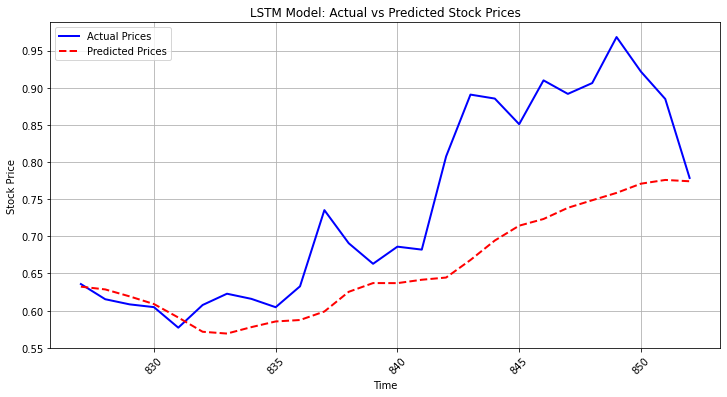

In [14]:
# Ensure the timestamps in the index are aligned with the predictions
aligned_dates = df_test.index[-len(predictions):]  # Get corresponding datetime values

plt.figure(figsize=(12, 6))
plt.plot(aligned_dates, y_test_original[-len(predictions):], label="Actual Prices", color='blue', linewidth=2)
plt.plot(aligned_dates, predictions, label="Predicted Prices", color='red', linestyle="dashed", linewidth=2)

# Formatting
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.title("LSTM Model: Actual vs Predicted Stock Prices")
plt.legend()
plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
plt.grid(True)

plt.show()



In [15]:
predictions

array([[0.6322598 ],
       [0.6285471 ],
       [0.61918515],
       [0.6088704 ],
       [0.5907801 ],
       [0.57157826],
       [0.56916153],
       [0.5777977 ],
       [0.5854502 ],
       [0.587387  ],
       [0.5988288 ],
       [0.62534195],
       [0.63709086],
       [0.6370102 ],
       [0.6415599 ],
       [0.6445395 ],
       [0.6681437 ],
       [0.6943624 ],
       [0.7143226 ],
       [0.7233029 ],
       [0.73835266],
       [0.748532  ],
       [0.75844216],
       [0.7708167 ],
       [0.7758577 ],
       [0.774072  ]], dtype=float32)

In [16]:
pred = data[['Close']]
pred = pred[len(pred) - len(predictions): len(pred)]
pred['Close'] = y_test_original
pred["Preddicions"] = predictions
pred

,Close,Preddicions
Date,,
2025-03-20,0.635772,0.632260
2025-03-21,0.615353,0.628547
2025-03-24,0.608446,0.619185
2025-03-25,0.604715,0.608870
2025-03-26,0.577086,0.590780
2025-03-27,0.607589,0.571578
2025-03-28,0.622764,0.569162
2025-03-31,0.615857,0.577798
2025-04-01,0.604614,0.585450


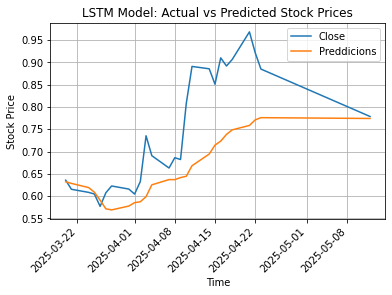

In [17]:
# Plot the DataFrame
pred.plot()

plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.title("LSTM Model: Actual vs Predicted Stock Prices")
plt.legend()
plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
plt.grid(True)


# Show the plot
plt.show()

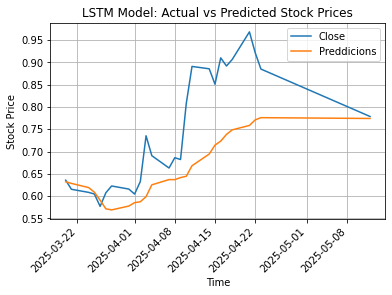

In [18]:
pred2 = pred.iloc[:100]
pred2.index = pd.to_datetime(pred2.index)
# Plot the DataFrame
pred2.plot()

plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.title("LSTM Model: Actual vs Predicted Stock Prices")
plt.legend()
plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
plt.grid(True)


# Show the plot
plt.show()

In [19]:
pred2

,Close,Preddicions
Date,,
2025-03-20,0.635772,0.632260
2025-03-21,0.615353,0.628547
2025-03-24,0.608446,0.619185
2025-03-25,0.604715,0.608870
2025-03-26,0.577086,0.590780
2025-03-27,0.607589,0.571578
2025-03-28,0.622764,0.569162
2025-03-31,0.615857,0.577798
2025-04-01,0.604614,0.585450


In [20]:
# Save the model to a file (for example, in HDF5 format)
model.save('lstm_stock_model.h5')


In [21]:
time_frame = mt5.TIMEFRAME_D1
bars = 300
# Define the feature columns used in training
window_size = 60

data = get_data(tickers, start, end, time_frame, bars)

features = []
for i in data.columns:
    features.append(i)

target = 'Close'

# Feature scaler (for technical indicators)
scaler_features = MinMaxScaler()
scaled_features = scaler_features.fit_transform(data[features])

# Target scaler (for Close price only)
scaler_target = MinMaxScaler()
scaled_target = scaler_target.fit_transform(data[[target]])

# Convert back to DataFrame for easy manipulation
df_scaled = pd.DataFrame(scaled_features, columns=features)

In [22]:
data

,Open,High,Low,Close,tick_volume,RSI,Williams_%R,WMA,HMA,EMA,SMA,TEMA,CCI,CMO,MACD,PPO,ROC,DMI,MFI
Date,,,,,,,,,,,,,,,,,,,
2024-10-09,1.09770,1.09809,1.09360,1.09372,34077,35.069675,-99.568345,1.107421,1.109122,1.103149,1.105379,1.109413,-117.333185,-49.326265,-0.002392,-0.216321,-1.554469,23.233796,43.216855
2024-10-10,1.09379,1.09548,1.09000,1.09346,39054,34.841763,-88.980892,1.106953,1.107536,1.102769,1.105666,1.107807,-114.134193,-50.408479,-0.002992,-0.270872,-2.181867,24.051604,36.006148
2024-10-11,1.09249,1.09537,1.09095,1.09362,29090,35.121190,-88.471338,1.106481,1.105903,1.102410,1.105718,1.106335,-95.355318,-43.262765,-0.003416,-0.309461,-1.759776,24.810997,42.043010
2024-10-14,1.09300,1.09365,1.08879,1.09081,27823,32.486251,-93.805581,1.105896,1.104193,1.101955,1.105633,1.104652,-99.251582,-74.903047,-0.003933,-0.356629,-2.393608,25.832663,35.652127
2024-10-15,1.09045,1.09165,1.08817,1.08907,32951,30.938408,-97.247706,1.105247,1.102406,1.101450,1.105558,1.102896,-98.637962,-72.710843,-0.004433,-0.402267,-2.438434,26.870683,28.750690
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-06,1.13128,1.13805,1.12795,1.13654,72914,59.867046,-67.458510,1.116161,1.148431,1.105698,1.100964,1.148348,-50.054024,-4.240472,0.009880,0.879884,-0.214227,45.695758,61.520210
2025-05-07,1.13662,1.13777,1.12913,1.12948,85320,54.626569,-90.432802,1.117280,1.148710,1.106631,1.102589,1.148291,-75.838624,-8.477620,0.008891,0.791467,-1.891840,44.965440,54.157825
2025-05-08,1.12948,1.13358,1.12115,1.12224,82893,49.811211,-96.982281,1.118050,1.148453,1.107243,1.104241,1.147357,-154.433443,-20.335277,0.007437,0.662109,-1.733740,42.935552,47.484108


In [23]:
window_size = 60  # Lookback period
X_test, y_test = [], []


# Test sequences
for i in range(window_size, len(df_scaled)):
    X_test.append(df_scaled.iloc[i-window_size:i].values)
    y_test.append(df_scaled.iloc[i]['Close'])

# Convert lists to numpy arrays)
X_test, y_test = np.array(X_test), np.array(y_test)

X_test.shape

(93, 60, 19)

In [24]:
predictions = model.predict(X_test)
predictions = scaler_target.inverse_transform(predictions.reshape(-1, 1))
y_test_original = scaler_target.inverse_transform(y_test.reshape(-1, 1))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step 


In [25]:
pred = []
for i in predictions:
    pred.append(i[0])

predictions = pred

In [26]:
pred = data[['Close']]
pred = pred[len(pred) - len(predictions): len(pred)]
pred['Close'] = y_test_original
pred["Prediction"] = predictions
pred

,Close,Prediction
Date,,
2025-01-02,1.02558,1.037391
2025-01-03,1.03078,1.035718
2025-01-06,1.03860,1.034267
2025-01-07,1.03364,1.034197
2025-01-08,1.03149,1.034286
...,...,...
2025-05-06,1.13654,1.115687
2025-05-07,1.12948,1.116720
2025-05-08,1.12224,1.116009


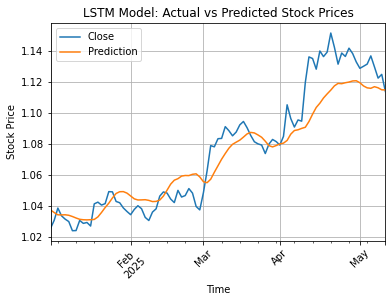

In [27]:
import matplotlib.pyplot as plt

# Plot the DataFrame
pred.plot()

plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.title("LSTM Model: Actual vs Predicted Stock Prices")
plt.legend()
plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
plt.grid(True)



# Show the plot
plt.show()

In [28]:
def backtest_strategy(df):
    """
    Backtests the trading strategy using the given DataFrame.
    
    Parameters:
        df (pd.DataFrame): DataFrame containing 'Close' and 'Prediction' columns.
        
    Returns:
        pd.DataFrame: DataFrame with signals, positions, PnL, and trade results.
    """
    df['Signal'] = 'HOLD'  # Initialize with 'HOLD'
    df['Position'] = 0     # 1 for BUY, -1 for SELL, 0 for HOLD

    current_position = 0   # 1 for BUY, -1 for SELL, 0 for HOLD
    entry_price = 0.0      # Price at which the position was opened
    
    for i in range(1, len(df)):
        prev_pred = df['Prediction'].iloc[i - 1]
        curr_pred = df['Prediction'].iloc[i]

        # Generate trading signals
        if curr_pred > prev_pred and current_position != 1:
            # BUY signal
            df.at[df.index[i], 'Signal'] = 'BUY'
            current_position = 1
            entry_price = df['Close'].iloc[i]
            df.at[df.index[i], 'Position'] = 1
        
        elif curr_pred < prev_pred and current_position != -1:
            # SELL signal
            df.at[df.index[i], 'Signal'] = 'SELL'
            current_position = -1
            entry_price = df['Close'].iloc[i]
            df.at[df.index[i], 'Position'] = -1
        
                
    return df

# Run the backtest on your DataFrame
backtest_df = backtest_strategy(pred.copy())

backtest_df

,Close,Prediction,Signal,Position
Date,,,,
2025-01-02,1.02558,1.037391,HOLD,0
2025-01-03,1.03078,1.035718,SELL,-1
2025-01-06,1.03860,1.034267,HOLD,0
2025-01-07,1.03364,1.034197,HOLD,0
2025-01-08,1.03149,1.034286,BUY,1
...,...,...,...,...
2025-05-06,1.13654,1.115687,HOLD,0
2025-05-07,1.12948,1.116720,BUY,1
2025-05-08,1.12224,1.116009,SELL,-1


In [29]:
def backtest_strategy(df):
    positions = []  # To store the opened positions
    results = []    # To store the results of each trade
    open_position = None
    entry_price = 0.0

    for idx, row in df.iterrows():
        signal = row['Signal']
        close_price = row['Close']

        if signal in ['BUY', 'SELL'] and open_position is None:
            # Open a new position
            open_position = signal
            entry_price = close_price
            positions.append((idx, signal, entry_price))

        elif signal == 'HOLD' and open_position is not None:
            # Close the position
            exit_price = close_price
            pnl = (exit_price - entry_price) if open_position == 'BUY' else (entry_price - exit_price)
            results.append({
                'entry_date': positions[-1][0],
                'exit_date': idx,
                'position': open_position,
                'entry_price': entry_price,
                'exit_price': exit_price,
                'pnl': pnl
            })
            open_position = None

    # Convert results to a DataFrame
    results_df = pd.DataFrame(results)
    results_df['cumulative_pnl'] = results_df['pnl'].cumsum()

    # Calculate total profit and win rate
    total_profit = results_df['pnl'].sum()
    wins = results_df[results_df['pnl'] > 0].shape[0]
    total_trades = results_df.shape[0]
    win_rate = wins / total_trades if total_trades > 0 else 0

    print(f'Total Profit: {total_profit}')
    print(f'Win Rate: {win_rate * 100:.2f}%')

    return results_df



results_df = backtest_strategy(backtest_df)

Total Profit: -0.012290000000000134
Win Rate: 33.33%
